In [ ]:
# import ROOT
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import uproot
import awkward as ak
import pandas as pd
from scipy.optimize import curve_fit


In [2]:
file_path = "/raid1/genli/Data_D2O/M2_data/run573_processed_H2O_v5.root"
with uproot.open(file_path) as file:
    # List all objects inside the ROOT file
    print(file.keys())  # Shows all keys (trees, histograms, etc.)

['starttime;1', 'tree;44', 'tree;43']


In [3]:
with uproot.open(file_path) as file:
    tree = file["tree"]  # Load the latest cycle of "tree"
    print(tree.keys())  # Print all available branches


['eventID', 'nSamples', 'adcVal', 'baselineMean', 'baselineRMS', 'pulseH', 'area', 'peakPosition', 'nsTime', 'triggerBits']


In [4]:
with uproot.open(file_path) as file:
    tree = file["tree"]
    ak_array = tree.arrays(library="ak")

# Convert scalar branches (1D) to Pandas
scalar_branches = ["eventID", "nsTime", "triggerBits"]
df = pd.DataFrame({key: ak.to_numpy(ak_array[key]) for key in scalar_branches})

# Convert fixed-size arrays (23 elements each) and store as NumPy arrays
array_branches = ["nSamples", "baselineMean", "baselineRMS", "pulseH", "area", "peakPosition"]
for key in array_branches:
    df[key] = list(ak.to_numpy(ak_array[key]))  # Store arrays inside cells

# Convert multi-dimensional arrays (e.g., adcVal[23][45]) as NumPy arrays inside cells
multi_array_branches = ["adcVal"]
for key in multi_array_branches:
    df[key] = list(ak.to_numpy(ak_array[key]))

# Show first row
print(df.head())

# Save DataFrame (arrays remain inside cells)
df.to_pickle("/raid1/genli/Data_D2O/run19529_data.pkl")

   eventID    nsTime  triggerBits  \
0        0   4560040           34   
1        2   5889880           32   
2        5  10303688           32   
3        6  10464440           32   
4        8  15940648           32   

                                            nSamples  \
0  [45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 4...   
1  [45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 4...   
2  [45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 4...   
3  [45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 4...   
4  [45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 4...   

                                        baselineMean  \
0  [200.95, 200.25, 200.25, 199.65, 200.7, 200.35...   
1  [199.7, 200.35, 199.2, 198.6, 200.25, 199.75, ...   
2  [200.2, 200.05, 200.1, 198.9, 200.35, 199.5, 1...   
3  [200.45, 200.15, 199.85, 198.8, 200.35, 199.75...   
4  [199.65, 200.05, 200.1, 198.45, 200.05, 200.35...   

                                         baselineRMS  \
0  [2.0118399538730705, 1.6393596310755, 0.7664

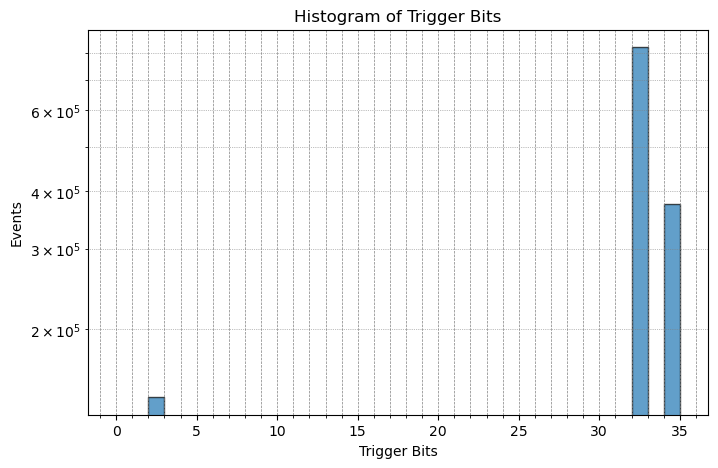

In [5]:
# Extract triggerBits column
trigger_bits = df["triggerBits"].to_numpy()

# Plot histogram in log scale
plt.figure(figsize=(8, 5))
bins_array = np.linspace(0, 35, 36)
plt.hist(trigger_bits, bins=bins_array, edgecolor='black', alpha=0.7)
plt.xlabel("Trigger Bits")
plt.ylabel("Events")
plt.yscale("log")
plt.title("Histogram of Trigger Bits")
# Enable minor ticks so that the grid has more reference points.
plt.minorticks_on()

# Configure grid lines for both major and minor ticks:
plt.grid(which='major', axis='y', linestyle='-', linewidth=0.75, color='gray')
plt.grid(which='minor', axis='y', linestyle=':', linewidth=0.5, color='gray')

# If you also want vertical grid lines:
plt.grid(which='both', axis='x', linestyle='--', linewidth=0.5, color='gray')

plt.savefig("/raid1/genli/Data_D2O/run19529_trigger_bits.png")
plt.show()


In [6]:
#create a new df only contain eventID, summation 0-11 of adcVal, and triggerBits
df_new = df[['eventID','triggerBits', 'nsTime']]
df_new['sum_area'] = df['area'].apply(lambda x: sum(x[0:11]))
print(df_new.head())

# Save DataFrame (arrays remain inside cells)
df_new.to_pickle("/raid1/genli/Data_D2O/run19529_data_new.pkl")

   eventID  triggerBits    nsTime  sum_area
0        0           34   4560040  57154.70
1        2           32   5889880     48.15
2        5           32  10303688     24.15
3        6           32  10464440    -15.40
4        8           32  15940648     45.60


/tmp/ipykernel_376149/298673196.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['sum_area'] = df['area'].apply(lambda x: sum(x[0:11]))


Analysis

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import uproot
import awkward as ak
import pandas as pd
from scipy.optimize import curve_fit
#plot histogram of sum_area for triggerBits = 2 and for all triggerBits, in log scale
#load the new df from the saved file
df_new = pd.read_pickle("/raid1/genli/Data_D2O/run19529_data_new.pkl")
#extract the sum_area column
# Prepare the data for plotting.
all_sums = df_new['sum_area'].to_numpy()
trigger2_sums = df_new.loc[df_new['triggerBits'] == 2, 'sum_area'].to_numpy()

In [8]:
#print shape of the two arrays
print(all_sums.shape)
print(trigger2_sums.shape)

(1342263,)
(142296,)


In [9]:
print(trigger2_sums)

[1550.65 1859.1   860.45 ... 1133.1  1537.3  1441.15]


Downsampled all_sums size: (1342263,)
Downsampled trigger2_sums size: (142296,)


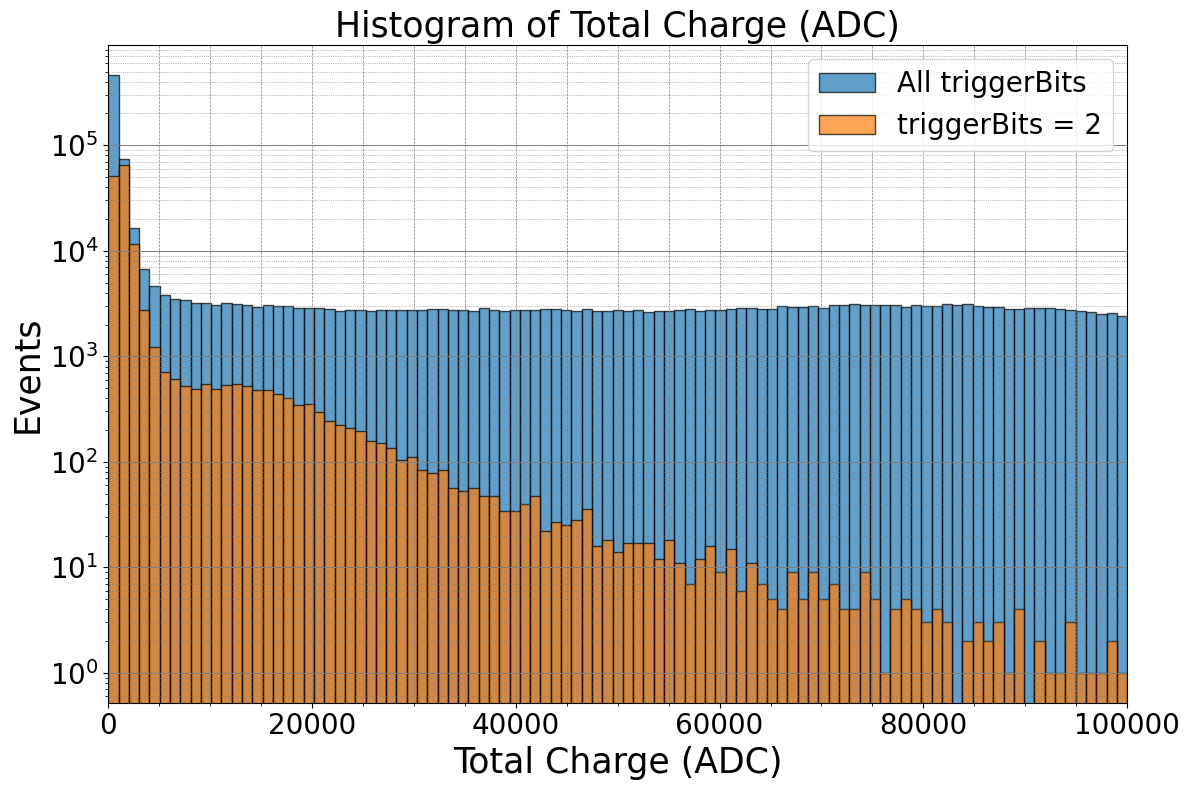

In [10]:
# Define the fraction of events to sample (1% here)
fraction = 1.0

# Generate random indices for each array
idx_all = np.random.choice(len(all_sums), size=int(len(all_sums) * fraction), replace=False)
idx_trigger2 = np.random.choice(len(trigger2_sums), size=int(len(trigger2_sums) * fraction), replace=False)

# Use the indices to obtain the downsampled arrays
sample_all_sums = all_sums[idx_all]
sample_trigger2_sums = trigger2_sums[idx_trigger2]

# Debug: Optionally print the sizes of the downsampled arrays
print("Downsampled all_sums size:", sample_all_sums.shape)
print("Downsampled trigger2_sums size:", sample_trigger2_sums.shape)

# Create the figure and plot the two histograms on the same figure
plt.figure(figsize=(12, 8))
bins_num = 100  # Adjust the number of bins as needed
#create bins for the histogram
bins_p = np.linspace(0, 100000, bins_num)

plt.hist(sample_all_sums, bins = bins_p, alpha=0.7, edgecolor='black', label='All triggerBits')
plt.hist(sample_trigger2_sums, bins = bins_p, alpha=0.7, edgecolor='black', label='triggerBits = 2')

plt.xlabel("Total Charge (ADC)", fontsize=25)
plt.ylabel("Events", fontsize=25)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.title("Histogram of Total Charge (ADC)", fontsize=25)
plt.yscale("log")
plt.legend(fontsize=20)

# Enable minor ticks and configure grid lines
plt.minorticks_on()
plt.grid(which='major', axis='y', linestyle='-', linewidth=0.75, color='gray')
plt.grid(which='minor', axis='y', linestyle=':', linewidth=0.5, color='gray')
plt.grid(which='both', axis='x', linestyle='--', linewidth=0.5, color='gray')

plt.xlim(0, 100000)
plt.tight_layout()

# Save the figure as a JPEG file before displaying it
plt.savefig("/raid1/genli/Data_D2O/run19529_histogram.jpeg")
plt.show()

In [11]:
#load the new df_new from the saved file
df_new = pd.read_pickle("/raid1/genli/Data_D2O/run19529_data_new.pkl")

# Define masks for muon events and after-veto events.
# Muon events are defined as those with triggerBits >= 32.
# After-veto events are defined as those with triggerBits == 2.
muon_mask = df_new['triggerBits'] >= 32
after_veto_mask = df_new['triggerBits'] == 2

# Extract muon event times and after-veto events.
muon_times = df_new.loc[muon_mask, 'nsTime'].values
after_veto_df_new = df_new.loc[after_veto_mask].copy()
event_times = after_veto_df_new['nsTime'].values

# Compute delta_t for each after-veto event.
# Since the DataFrame is already sorted, we can use np.searchsorted to find the last muon event before each after-veto event.
insertion_indices = np.searchsorted(muon_times, event_times, side='right')

# Initialize delta_t with NaN (for events with no preceding muon)
delta_t = np.full_like(event_times, np.nan, dtype=float)
valid = insertion_indices > 0
delta_t[valid] = event_times[valid] - muon_times[insertion_indices[valid] - 1]

# Add delta_t as a new column to the after-veto DataFrame.
after_veto_df_new['delta_t'] = delta_t

# Define time thresholds (convert µs to ns: 10 µs = 10,000 ns, 20 µs = 20,000 ns)
threshold_short = 10_000   # 10 µs in ns
threshold_long  = 20_000   # 20 µs in ns

# Select two groups of after-veto events based on delta_t:
group1 = after_veto_df_new[after_veto_df_new['delta_t'] < threshold_short]
group2 = after_veto_df_new[after_veto_df_new['delta_t'] > threshold_long]


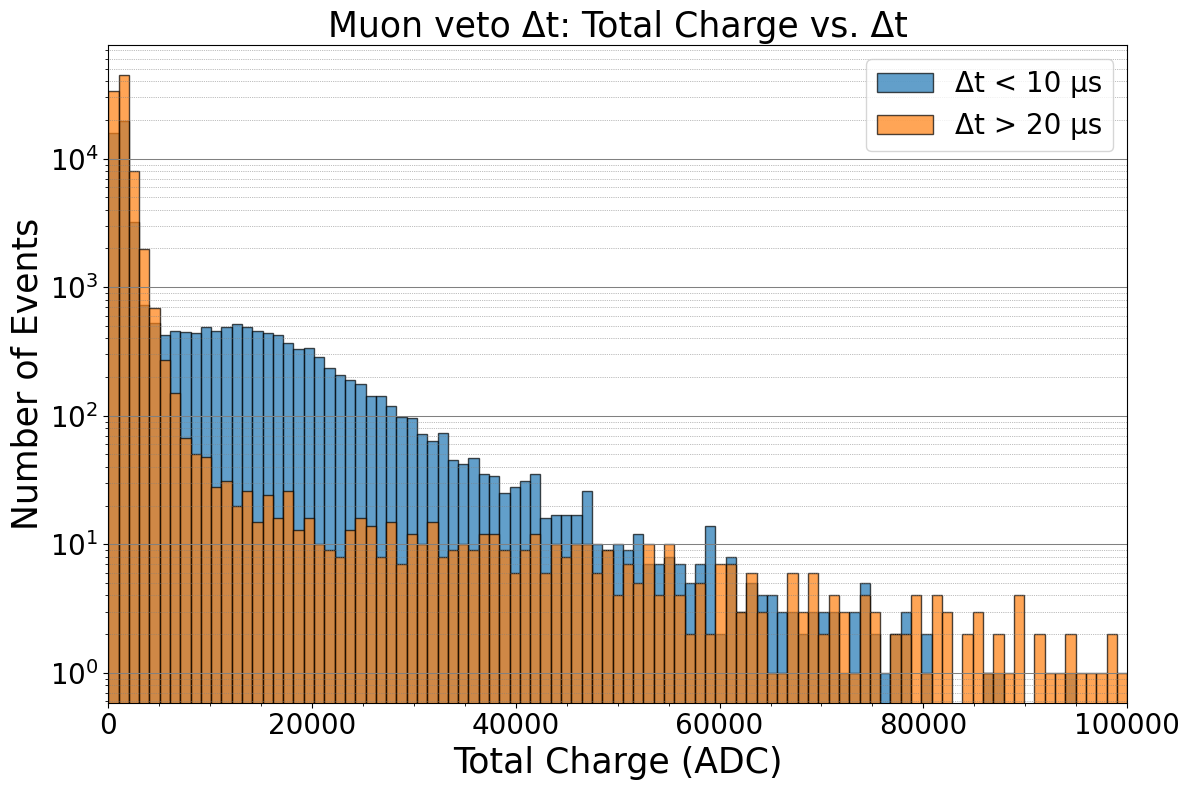

In [12]:
# # Define the fraction of data to sample (e.g., 1%).
fraction = 1.0

# Downsample group1 and group2 using DataFrame.sample (using a random_state for reproducibility).
group1_sample = group1.sample(frac=fraction, random_state=42)
group2_sample = group2.sample(frac=fraction, random_state=42)

plt.figure(figsize=(12, 8))
#create bins for the histogram
bins_p = np.linspace(0, 100000, bins_num)

plt.hist(group1_sample['sum_area'], bins=bins_p, alpha=0.7, edgecolor='black',
         label='Δt < 10 µs')
plt.hist(group2_sample['sum_area'], bins=bins_p, alpha=0.7, edgecolor='black',
         label='Δt > 20 µs')

plt.xlabel("Total Charge (ADC)", fontsize=25)
plt.xlim(0, 100000)
plt.xticks(fontsize=20)
plt.ylabel("Number of Events", fontsize=25)
plt.yticks(fontsize=20)
plt.title("Muon veto Δt: Total Charge vs. Δt", fontsize=25)
plt.yscale("log")
plt.legend(fontsize=20)

# Enable minor ticks so that the grid has more reference points.
plt.minorticks_on()
plt.grid(which='major', axis='y', linestyle='-', linewidth=0.75, color='gray')
plt.grid(which='minor', axis='y', linestyle=':', linewidth=0.5, color='gray')
plt.tight_layout()

#save it as a jpeg file
plt.savefig("/raid1/genli/Data_D2O/run19529_histogram_muon_veto_deltaT.jpeg")
plt.show()

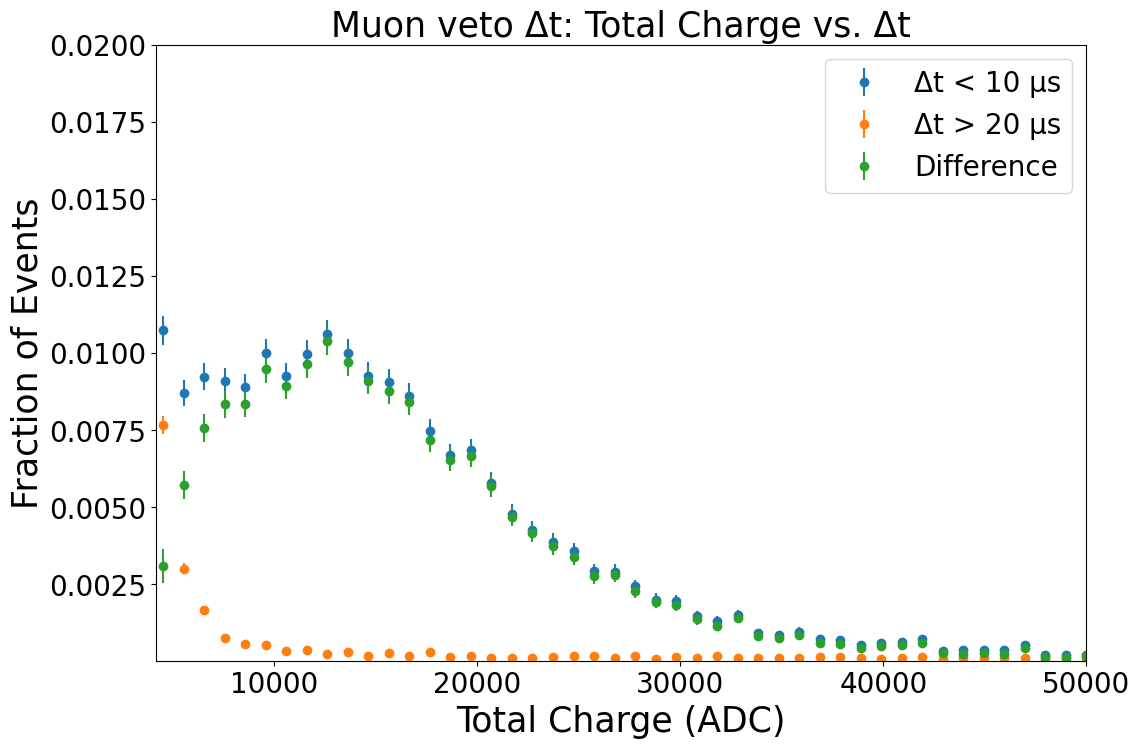

In [13]:
#save the number of events in each column in hist for group1 and group2
group1_hist, group1_xedges = np.histogram(group1_sample['sum_area'], bins=bins_p)
group2_hist, group2_xedges = np.histogram(group2_sample['sum_area'], bins=bins_p)

# Compute the bin centers from the bin edges.
group1_bin_centers = 0.5 * (group1_xedges[:-1] + group1_xedges[1:])
group2_bin_centers = 0.5 * (group2_xedges[:-1] + group2_xedges[1:])

#Normalize the histograms based on the number of events in each group
group1_hist_norm = group1_hist / len(group1_sample)
group2_hist_norm = group2_hist / len(group2_sample)

# Calculate the difference between the normalized histograms.
hist_diff = group1_hist_norm - group2_hist_norm

#Calculate error bars for the normalized histograms
group1_hist_err = np.sqrt(group1_hist) / len(group1_sample)
group2_hist_err = np.sqrt(group2_hist) / len(group2_sample)
hist_diff_err = np.sqrt(group1_hist_err**2 + group2_hist_err**2)

# Plot the normalized histograms.
plt.figure(figsize=(12, 8))
plt.errorbar(group1_bin_centers, group1_hist_norm, yerr=group1_hist_err, fmt='o', label='Δt < 10 µs')
plt.errorbar(group2_bin_centers, group2_hist_norm, yerr=group2_hist_err, fmt='o', label='Δt > 20 µs')
plt.errorbar(group1_bin_centers, hist_diff, yerr=hist_diff_err, fmt='o', label='Difference')

plt.xlabel("Total Charge (ADC)", fontsize=25)
plt.ylabel("Fraction of Events", fontsize=25)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.title("Muon veto Δt: Total Charge vs. Δt", fontsize=25)
plt.xlim(4200, 50000)
plt.ylim(1e-5, 2e-2)

plt.legend(fontsize=20)


/tmp/ipykernel_376149/2108041478.py:5: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * x) + c


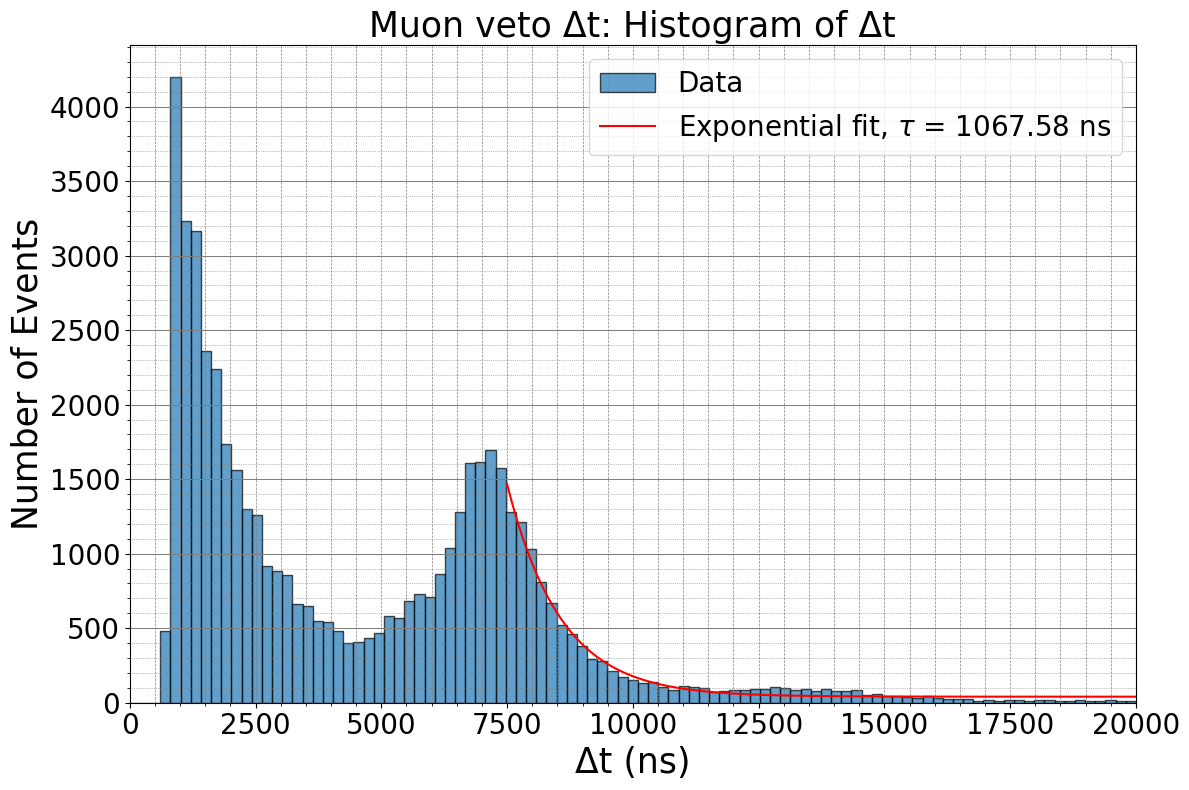

In [14]:
# Define the time threshold for the exponential fit.
time_threshold = 20_000  # in ns

def exponential(x, a, b, c):
    return a * np.exp(-b * x) + c

# Define the histogram binning.
bins = np.linspace(0, time_threshold, bins_num)
hist, bin_edges = np.histogram(after_veto_df_new['delta_t'], bins=bins)

# Calculate the bin centers.
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Set fitting range.
start_dt = 7500
end_dt = 20_000
idx_start = np.searchsorted(bin_centers, start_dt)
idx_end = np.searchsorted(bin_centers, end_dt)

# Fit the histogram data with the exponential decay function.
popt, pcov = curve_fit(exponential, bin_centers[idx_start:idx_end], hist[idx_start:idx_end], p0=[1, 1e-3, 1])

# Plot the histogram.
plt.figure(figsize=(12, 8))
plt.hist(after_veto_df_new['delta_t'], bins=bins, alpha=0.7, edgecolor='black', label='Data')
plt.xlabel("Δt (ns)", fontsize=25)
plt.ylabel("Number of Events", fontsize=25)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
# plt.yscale("log")
plt.title("Muon veto Δt: Histogram of Δt", fontsize=25)
plt.legend(fontsize=20)

# Enable minor ticks so that the grid has more reference points.
plt.minorticks_on()
plt.grid(which='major', axis='y', linestyle='-', linewidth=0.75, color='gray')
plt.grid(which='minor', axis='y', linestyle=':', linewidth=0.5, color='gray')
plt.grid(which='both', axis='x', linestyle='--', linewidth=0.5, color='gray')
plt.xlim(0, time_threshold)
plt.tight_layout()

# Plot the fitted curve.
x_fit = np.linspace(start_dt, end_dt, 1000)
y_fit = exponential(x_fit, *popt)
plt.plot(x_fit, y_fit, 'r-', label='Exponential fit, $\\tau$ = {:.2f} ns'.format(1 / popt[1]))
plt.legend(fontsize=20)

plt.show()

In [15]:
# Define time thresholds (convert µs to ns: 10 µs = 10,000 ns, 20 µs = 20,000 ns)
threshold_peak1_l = 0
threshold_peak1_r = 4500

threshold_peak2_l = 4500
threshold_peak2_r = 10000

# Select two groups of after-veto events based on delta_t:
group_p1 = after_veto_df_new[after_veto_df_new['delta_t'] < threshold_peak1_r]
group_p2 = after_veto_df_new[(after_veto_df_new['delta_t'] > threshold_peak2_l) & (after_veto_df_new['delta_t'] < threshold_peak2_r)]

In [16]:
group_p1['sum_area'].max()
group_p2['sum_area'].max()

74176.30000000002

<Figure size 1200x800 with 0 Axes>

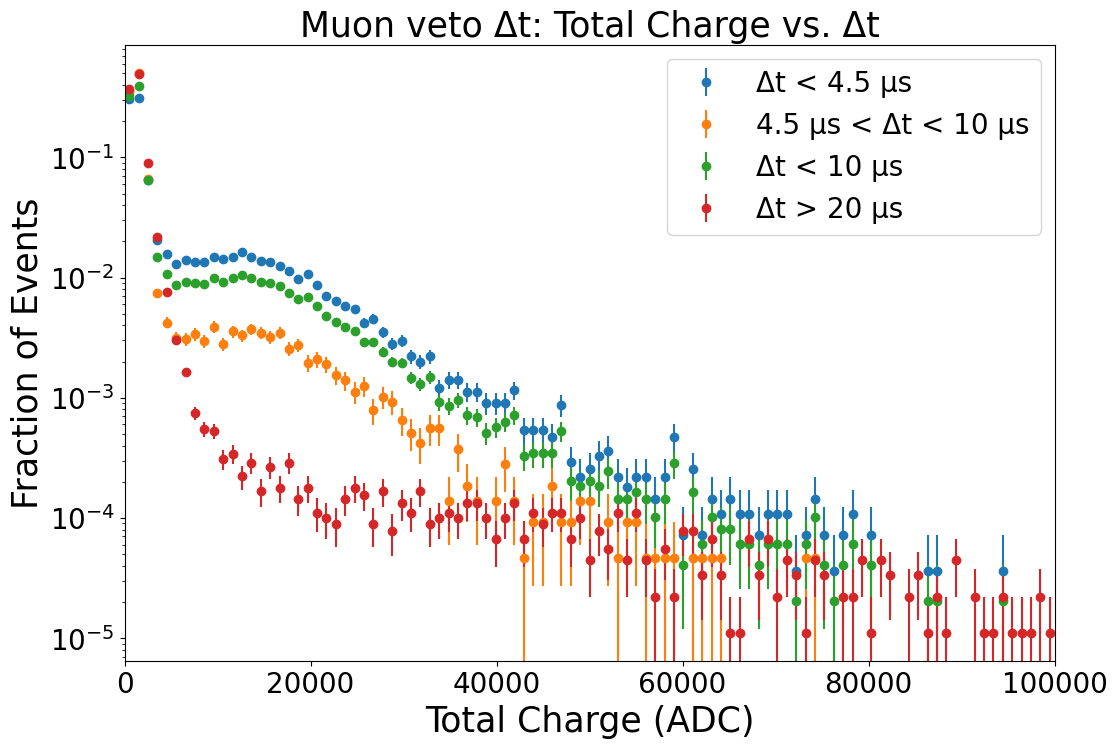

In [17]:
#draw the histogram of total charge for the two groups
plt.figure(figsize=(12, 8))
bins_low = np.linspace(0, 100_000, bins_num)
group_p1_hist, group_p1_xedges = np.histogram(group_p1['sum_area'], bins=bins_low)
group_p2_hist, group_p2_xedges = np.histogram(group_p2['sum_area'], bins=bins_low)

# Compute the bin centers from the bin edges.
center_p1 = 0.5 * (group_p1_xedges[:-1] + group_p1_xedges[1:])
center_p2 = 0.5 * (group_p2_xedges[:-1] + group_p2_xedges[1:])

#Normalize the histograms based on the number of events in each group
norm_p1 = group_p1_hist / len(group_p1)
norm_p2 = group_p2_hist / len(group_p2)

# Calculate the difference between the normalized histograms.
diff_norm = norm_p1 - norm_p2

#Calculate error bars for the normalized histograms
err_p1 = np.sqrt(group_p1_hist) / len(group_p1)
err_p2 = np.sqrt(group_p2_hist) / len(group_p2)
err_diff = np.sqrt(err_p1**2 + err_p2**2)

# Plot the normalized histograms.
plt.figure(figsize=(12, 8))
plt.errorbar(center_p1, norm_p1, yerr=err_p1, fmt='o', label='Δt < 4.5 µs')
plt.errorbar(center_p2, norm_p2, yerr=err_p2, fmt='o', label='4.5 µs < Δt < 10 µs')
# plt.errorbar(center_p1, diff_norm, yerr=err_diff, fmt='o', label='Difference')
plt.errorbar(center_p1, group1_hist_norm, yerr=group1_hist_err, fmt='o', label='Δt < 10 µs')
plt.errorbar(center_p2, group2_hist_norm, yerr=group2_hist_err, fmt='o', label='Δt > 20 µs')
plt.xlabel("Total Charge (ADC)", fontsize=25)
plt.ylabel("Fraction of Events", fontsize=25)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.yscale("log")
plt.title("Muon veto Δt: Total Charge vs. Δt", fontsize=25)
plt.legend(fontsize=20)
plt.xlim(0, 100_000)

#save it as a jpeg file
plt.savefig("/raid1/genli/Data_D2O/run19529_histogram_muon_veto_diff_deltaT_cut.jpeg")
plt.show()


In [18]:
print(center_p1.shape)
print(group1_bin_centers.shape)
print(center_p1.max())
print(group1_bin_centers.max())
print(sum(norm_p1))
print(sum(norm_p2))
print(sum(group1_hist_norm))
print(sum(group2_hist_norm))

(99,)
(99,)
99494.94949494948
99494.94949494948
0.9963042139207952
0.9951677353405807
0.9958062743022333
0.9990039068984976


In [19]:
print(df['area'][0].shape)

(23,)


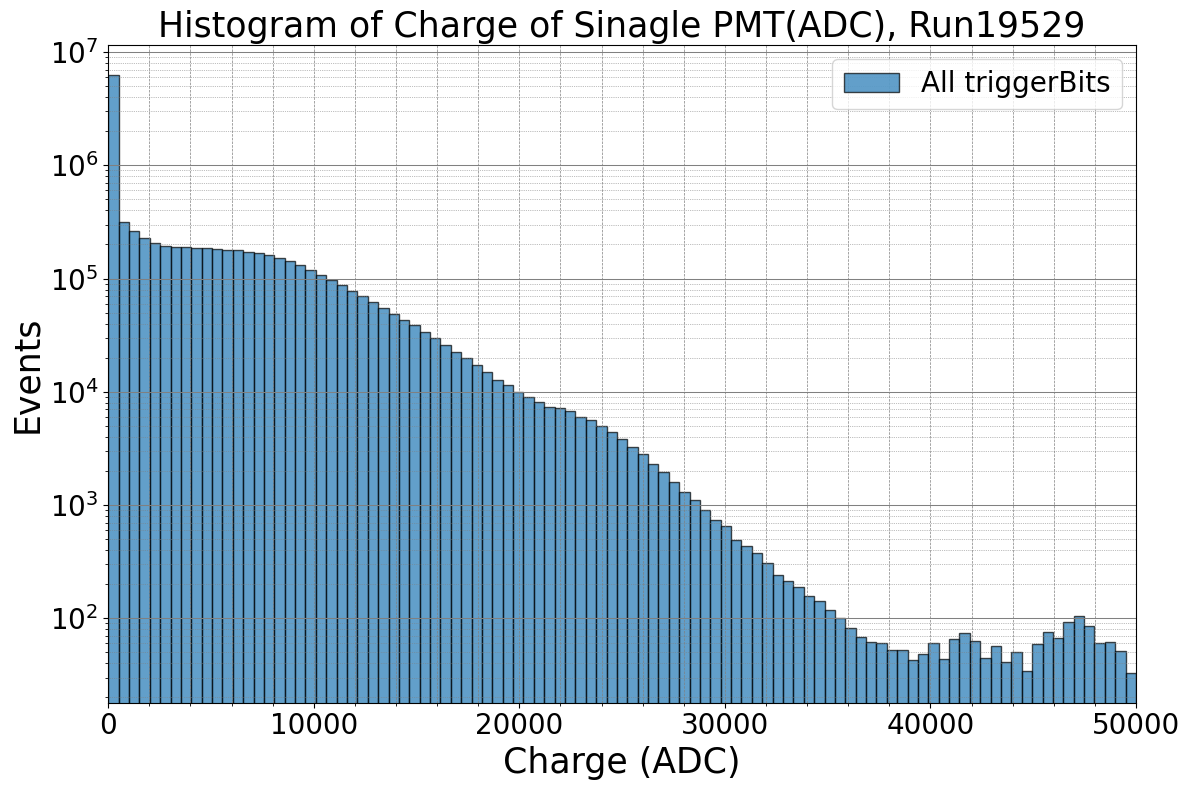

In [22]:
#plot hist of area
#area[i] is a list of 23 elements, we only want first 12 elements
area = df['area'].to_numpy()
area = np.concatenate(area).reshape(-1, 23)[:, :12].flatten()

plt.figure(figsize=(12, 8))
bins_num = 100  # Adjust the number of bins as needed
bins_p = np.linspace(0, 50000, bins_num)
plt.hist(area, bins = bins_p, alpha=0.7, edgecolor='black', label='All triggerBits')
plt.xlabel("Charge (ADC)", fontsize=25)
plt.ylabel("Events", fontsize=25)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.title("Histogram of Charge of Sinagle PMT(ADC), Run19529", fontsize=25)
plt.yscale("log")
plt.legend(fontsize=20)

# Enable minor ticks and configure grid lines
plt.minorticks_on()
plt.grid(which='major', axis='y', linestyle='-', linewidth=0.75, color='gray')
plt.grid(which='minor', axis='y', linestyle=':', linewidth=0.5, color='gray')
plt.grid(which='both', axis='x', linestyle='--', linewidth=0.5, color='gray')

plt.xlim(0, 50000)
plt.tight_layout()